# How do models work?

## Linear Regression 

### Data

In [9]:
import numpy as np

np.random.seed(42)
m = 100
X = 2 * np.random.rand(m, 1)
y = 4 + 3 * X + np.random.randn(m, 1)

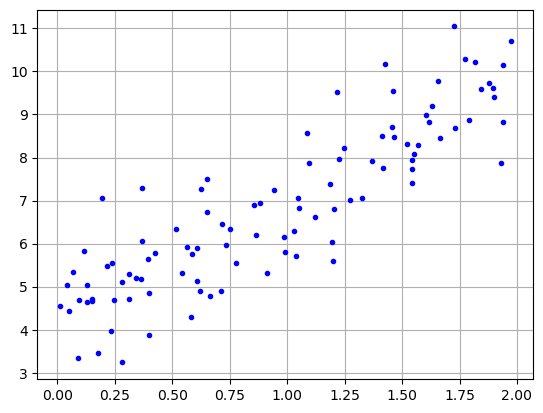

In [10]:
import matplotlib.pyplot as plt
plt.plot(X, y, "b.")
plt.grid(True)
plt.show()

In [11]:
from sklearn.preprocessing import add_dummy_feature
X_b = add_dummy_feature(X)
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
theta_best

array([[4.21509616],
       [2.77011339]])

In [12]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)
y_predict = X_new_b @ theta_best
y_predict

array([[4.21509616],
       [9.75532293]])

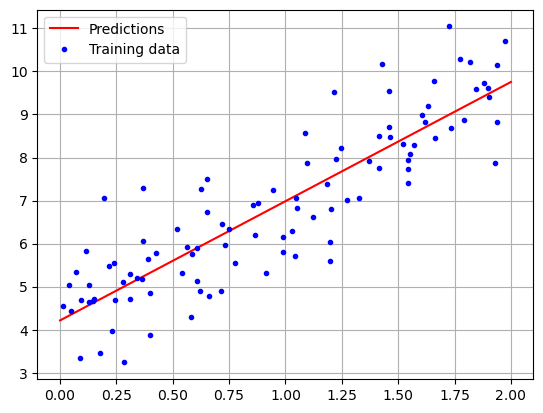

In [13]:
plt.plot(X_new, y_predict, "r-", label = "Predictions")
plt.plot(X, y, "b.", label = "Training data")
plt.grid(True)
plt.legend()
plt.show()

In [14]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.21509616]), array([[2.77011339]]))

In [15]:
lin_reg.predict(X_new)

array([[4.21509616],
       [9.75532293]])

### Gradient Descent step 

In [16]:
eta = 0.1
n_epochs = 1000
m = len(X_b)
np.random.seed(42)
theta = np.random.randn(2, 1)

for epoch in range(n_epochs):
    gradients = 2/m * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * gradients
    print(f"Epoch {epoch}: {theta.ravel()}")    

Epoch 0: [1.78737583 1.27927812]
Epoch 1: [2.55330471 2.10402371]
Epoch 2: [3.01093601 2.58105009]
Epoch 3: [3.28732561 2.85420804]
Epoch 4: [3.45706384 3.00792898]
Epoch 5: [3.56394378 3.0917658 ]
Epoch 6: [3.63368035 3.13479813]
Epoch 7: [3.68137641 3.15408821]
Epoch 8: [3.71590533 3.15964433]
Epoch 9: [3.74248352 3.15733444]
Epoch 10: [3.76418049 3.15059636]
Epoch 11: [3.78280532 3.14144163]
Epoch 12: [3.79942693 3.13104483]
Epoch 13: [3.81467957 3.12008943]
Epoch 14: [3.82894209 3.10897085]
Epoch 15: [3.8424432  3.09791559]
Epoch 16: [3.85532328 3.08705122]
Epoch 17: [3.86767063 3.0764474 ]
Epoch 18: [3.87954279 3.06613997]
Epoch 19: [3.89097907 3.05614512]
Epoch 20: [3.90200784 3.04646763]
Epoch 21: [3.91265093 3.03710577]
Epoch 22: [3.9229261  3.02805413]
Epoch 23: [3.93284861 3.01930529]
Epoch 24: [3.94243202 3.01085082]
Epoch 25: [3.95168881 3.00268179]
Epoch 26: [3.9606306  2.99478913]
Epoch 27: [3.96926843 2.98716385]
Epoch 28: [3.9776128  2.97979708]
Epoch 29: [3.98567378 2.

### SGD Learning schedule 

In [17]:
n_epochs = 50
t0, t1 = 5, 50

def learning_schedule(t):
    return t0 / (t + t1)

np.random.seed(42)
theta = np.random.randn(2, 1)

for epoch in range(n_epochs):
    for iteration in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T @ (xi @ theta - yi)
        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients

theta

array([[4.21076011],
       [2.74856079]])

# No linear data

### Polynomial Regression

In [24]:
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m,1) - 3
y_real= 0.5 * X**2 + X + 2
y_noisy = 0.5 * X**2 + X + 2 + np.random.randn(m,1)


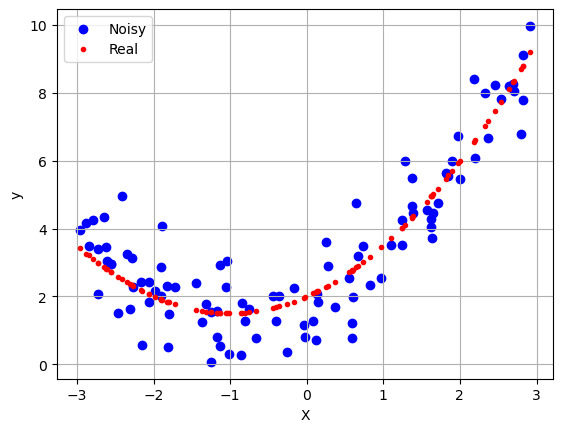

In [36]:
plt.scatter(X, y_noisy  , color="blue", label="Noisy")
plt.plot(X, y_real, "r.", label="Real")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

In [38]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
X[0]

array([-0.75275929])

In [39]:
X_poly[0]

array([-0.75275929,  0.56664654])

In [40]:
lin_reg= LinearRegression()
lin_reg.fit(X_poly, y_noisy)
lin_reg.intercept_, lin_reg.coef_

(array([1.78134581]), array([[0.93366893, 0.56456263]]))

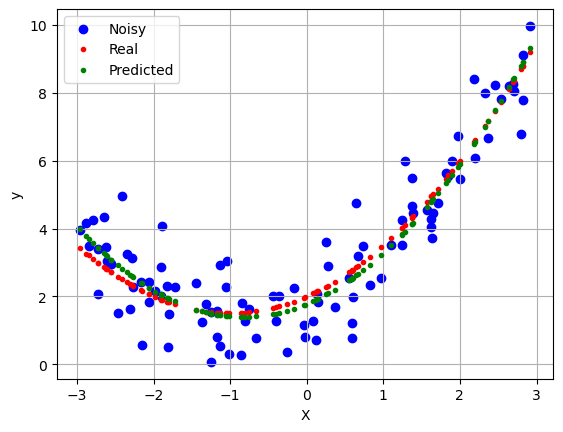

In [47]:
y_pred = 0.56456263 * X**2 + 0.93366893* X + 1.78134581
plt.scatter(X, y_noisy  , color="blue", label="Noisy")
plt.plot(X, y_real, "r.", label="Real")
plt.plot(X, y_pred, "g.", label="Predicted")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()